# Tarea Lab 01: imágenes como arreglos de NumPy

En este notebook trabajarás con 6 fotos que están en la carpeta `images/`.

Una imagen no es más que un arreglo de NumPy con forma `(alto, ancho, canales)`. Todo lo que viste en el notebook `introduccion_a_numpy.ipynb` (formas, indexación, slicing, tipos de datos, concatenación) se aplica directamente aquí.

**Objetivos**
1. Mostrar las 6 imágenes al mismo tiempo en una grilla de 3x2 (3 columnas por 2 filas).
2. Construir un mosaico: **un solo arreglo de NumPy** que contenga las 6 imágenes ordenadas en esa misma grilla.

**Entrega:** este mismo notebook con tu código en las celdas marcadas `# Tu código aquí` y todas las celdas ejecutadas (que se vean las salidas).

## Preparación

Primero instala las dependencias del proyecto y abre el notebook:

```bash
uv sync
uv run jupyter lab
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

rutas = [
    "images/numpy-panda.jpeg",
    "images/numpy-car-photo.png",
    "images/numpy-dog-photo.png",
    "images/dog-photo-2.jpeg",
    "images/dog-photo-3.jpeg",
    "images/unstructured-data-object-detection-self-driving-car.jpeg",
]

imagenes = [imread(ruta) for ruta in rutas]
len(imagenes)

6

Antes de empezar, mira con qué te estás enfrentando: las 6 imágenes **no** tienen la misma forma, ni el mismo número de canales, ni el mismo tipo de dato.

In [ ]:
for ruta, imagen in zip(rutas, imagenes):
    print(f"{ruta:35} shape={imagen.shape} dtype={imagen.dtype} min={imagen.min()} max={imagen.max()}")

images/numpy-panda.jpeg             shape=(852, 1280, 3) dtype=uint8 min=0 max=255
images/numpy-car-photo.png          shape=(431, 575, 4) dtype=float32 min=0.0 max=1.0
images/numpy-dog-photo.png          shape=(432, 575, 4) dtype=float32 min=0.0 max=1.0
images/dog-photo-2.jpeg             shape=(1536, 2048, 3) dtype=uint8 min=0 max=247
images/dog-photo-3.jpeg             shape=(1280, 960, 3) dtype=uint8 min=0 max=255
images/unstructured-data-object-detection-self-driving-car.jpeg shape=(225, 225, 3) dtype=uint8 min=0 max=255


Fíjate en las diferencias:

* Los `.jpeg` se cargan como enteros `uint8` con valores de 0 a 255.
* Los `.png` se cargan como flotantes `float32` con valores de 0.0 a 1.0.
* Los `.png` tienen 4 canales (RGBA: rojo, verde, azul y transparencia); los `.jpeg` tienen 3 (RGB).

Esas diferencias no molestan en la Tarea 1, pero son justamente el problema a resolver en la Tarea 2.

## Tarea 1: mostrar las 6 imágenes en una grilla de 3x2

Muestra las 6 imágenes en una sola figura, en una grilla de 3 columnas por 2 filas.

**Requisitos**
1. Usa una sola figura con `plt.subplots(nrows=2, ncols=3)`.
2. Cada imagen debe llevar como título el nombre del archivo y su forma, por ejemplo `numpy-panda.jpeg (852, 1280, 3)`.
3. Ningún subplot debe mostrar los ejes (números en los bordes).
4. La figura debe verse ordenada, sin títulos encimados.

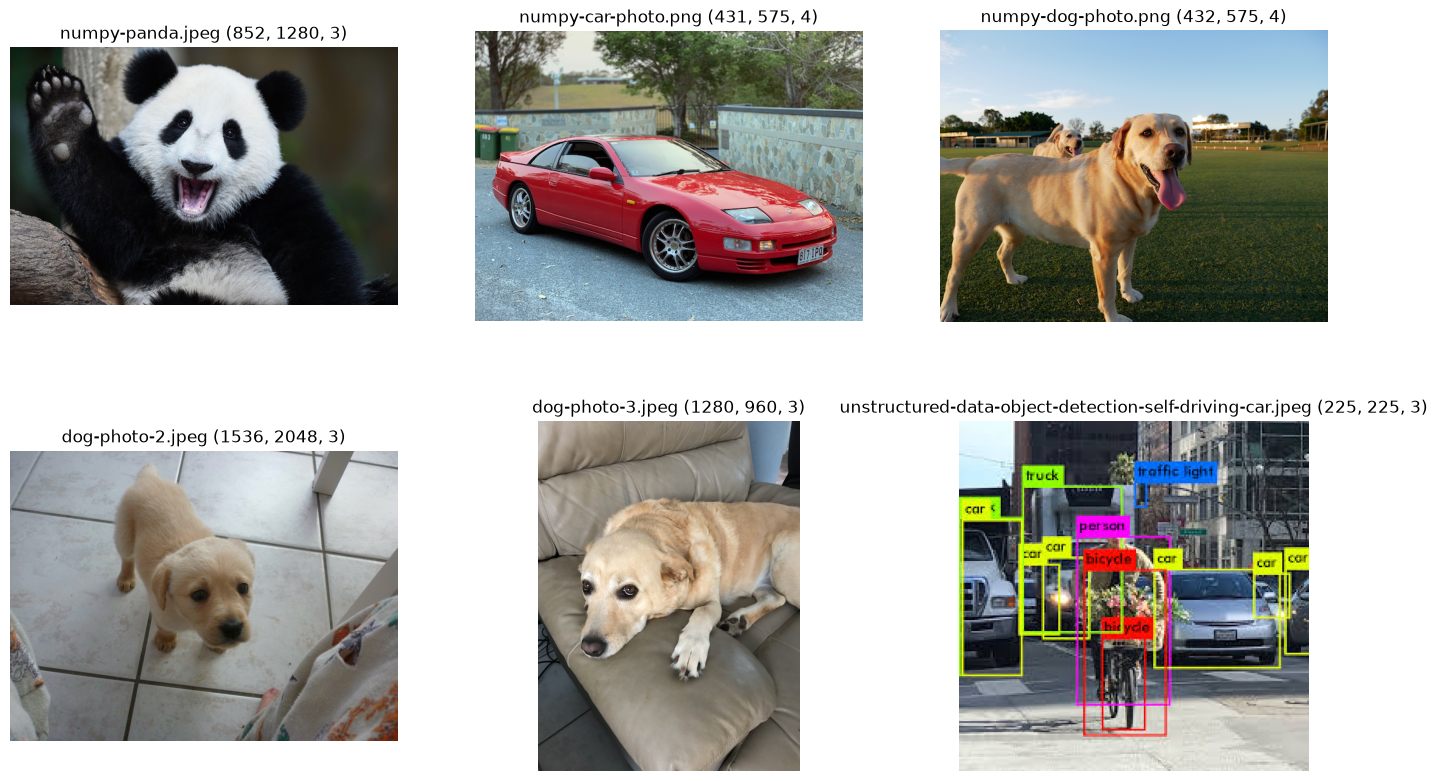

In [ ]:
# Tu código aquí
from pathlib import Path
nombres = rutas

figura, eje = plt.subplots(nrows=2, ncols=3, figsize=(17, 10))
lista_plana = eje.flatten()

for ruta, imagen, n_grafico in zip(rutas, imagenes, lista_plana):
    nueva_ruta = Path(f'{ruta}')
    nombre = nueva_ruta.name
    n_grafico.set_title(f'{nombre} {imagen.shape}')
    n_grafico.imshow(imagen)
    n_grafico.axis('off')

## Tarea 2: construir un mosaico con NumPy

Ahora arma el mosaico **sin matplotlib**: el resultado debe ser **un único arreglo de NumPy** con las 6 imágenes pegadas en la misma grilla de 3 columnas por 2 filas. Recién al final lo muestras con **una sola** llamada a `plt.imshow()`.

Para poder concatenar arreglos, todos tienen que coincidir en tipo de dato, número de canales y en la dimensión por la que los pegas. Estos son los pasos sugeridos:

1. **Deja todas las imágenes en 3 canales (RGB).** 
2. **Unifica el tipo de dato.**
3. **Unifica el alto y el ancho.** Agrega zonas negras para compenzar tamano de imagenes mas pequenas
4. **Concatena.**
5. **Verifica la forma.** 
6. **Muéstralo** con una sola llamada a `plt.imshow(mosaico)` y quita los ejes.

**Ojo:** no uses librerías de redimensionado (`PIL`, `cv2`, `skimage`). Todo el trabajo de esta tarea se hace con indexación y funciones de NumPy.

(np.float64(-0.5), np.float64(6143.5), np.float64(3071.5), np.float64(-0.5))

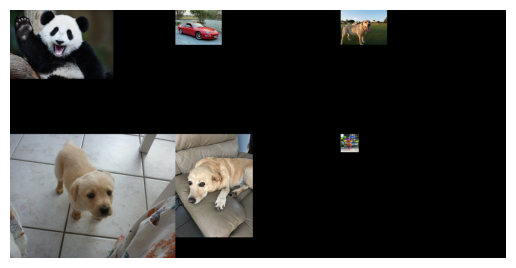

In [ ]:
# Tu código aquí
#for ruta, imagen in zip(rutas, imagenes):
#    print(f"{ruta:35} shape={imagen.shape} dtype={imagen.dtype} min={imagen.min()} max={imagen.max()}")

mosaico = []

i = 0

for imagen in imagenes:
    if imagen.max() == 1.0:
        imagen_rgb = imagen[:,:,:3] * 255
        imagen_rgb = imagen_rgb.astype('uint8')
        mosaico.append(imagen_rgb)
    else:
        mosaico.append(imagen)

for imagen in mosaico:
    imagen_negro = np.zeros((1536, 2048, 3), dtype='uint8')
    alto, ancho, canal = imagen.shape
    imagen_negro[:alto, :ancho, :] = imagen
    mosaico[i] = imagen_negro
    i += 1

imagen_1_2 = np.concatenate ((mosaico[0], mosaico[1]), axis=1)
imagen_1_2_3 = np.concatenate ((imagen_1_2, mosaico[2]), axis=1)

imagen_4_5 = np.concatenate ((mosaico[3], mosaico[4]), axis=1)
imagen_4_5_6 = np.concatenate ((imagen_4_5, mosaico[5]), axis=1)

imagen_final = np.concatenate ((imagen_1_2_3, imagen_4_5_6), axis=0)

plt.imshow(imagen_final)
plt.axis('off')



### Bonus (1 punto opcional)

Convierte tu mosaico a escala de grises promediando los 3 canales de color y muéstralo con `plt.imshow(mosaico_gris, cmap="gray")`.

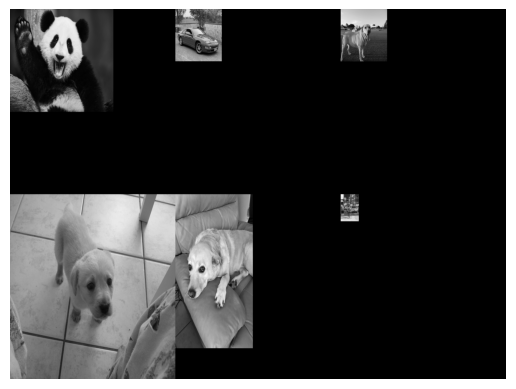

In [ ]:
# Tu código aquí (bonus)



rgb_weights = [0.2989, 0.5870, 0.1140]
imagen_gris = np.dot(imagen_final[..., :3], rgb_weights)
plt.axis('off')
plt.imshow(imagen_gris, cmap=plt.get_cmap("gray"), aspect='auto')

## Rúbrica

| Ítem | 0 punto | 2 puntos | 3 puntos |
|---|---|---|---|
| **Tarea 1: grilla 3x2** | Muestra las imágenes, pero no en una sola figura de 3x2, o faltan imágenes. | Las 6 imágenes en una sola figura de 3x2, pero con los títulos incompletos o con los ejes a la vista. | Las 6 imágenes en una sola figura de 3x2, cada una con su nombre y su forma, sin ejes y sin títulos encimados. |
| **Tarea 2: mosaico** | El mosaico no llega a armarse: quedan errores de forma, de tipo de dato o de canales al concatenar. | El mosaico se arma y se muestra, pero con algún defecto: colores alterados, imágenes mal ubicadas o más de un `imshow`. | Un único arreglo de NumPy con la forma esperada, mostrado con un solo `imshow`, con las 6 imágenes bien ubicadas en la grilla de 3x2. |

**Total: 6 puntos.** El Bonus no entra en la nota. Pero se puede utilizar en una solemne